<a href="https://www.kaggle.com/code/beakaletefera/asteroid-panic-level-classification?scriptVersionId=321424754" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

I bulit a binary classification machine learning algorithm that predicts whether an approaching asteroid would cause "high panic" or "low panic" based on publicly available asteroid dataset from Kaggle.

1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

2. Load the Data

In [2]:
ast_df = pd.read_csv('/kaggle/input/nasa-asteroid-impact-dataset/asteroid_dataset_20251019.csv')

3. View the First Rows

In [3]:
ast_df

,asteroid_designation,asteroid_fullname,close_approach_date,year,month,distance_au,velocity_km_s,absolute_magnitude,days_until_approach,is_past_event,is_future_event,risk_score,panic_level,threat_category,panic_verdict,on_sentry_list,sentry_impact_prob,sentry_torino_scale,sentry_palermo_scale,sentry_diameter_km
0,2020 AY1,(2020 AY1),2020-01-01 00:54:00,2020,1,0.021164,5.621422,25.30,-2119,True,False,0.384272,4,MONITOR,"Worth a tweet, not worth a bunker.",False,NaN,NaN,NaN,NaN
1,2019 YK,(2019 YK),2020-01-01 02:06:00,2020,1,0.036101,7.359263,24.10,-2119,True,False,0.362620,4,MONITOR,"Worth a tweet, not worth a bunker.",False,NaN,NaN,NaN,NaN
2,2013 EC20,(2013 EC20),2020-01-01 03:23:00,2020,1,0.162019,2.793701,29.00,-2119,True,False,0.189181,2,SAFE,You're fine. Go touch grass.,True,4.723700e-07,0.0,-8.94,0.0054
3,2020 AM1,(2020 AM1),2020-01-01 07:18:00,2020,1,0.159657,4.152938,24.70,-2119,True,False,0.100336,1,SAFE,You're fine. Go touch grass.,False,NaN,NaN,NaN,NaN
4,2020 AP3,(2020 AP3),2020-01-01 11:13:00,2020,1,0.016740,5.191250,26.60,-2118,True,False,0.391083,4,MONITOR,"Worth a tweet, not worth a bunker.",False,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89222,2024 FG2,(2024 FG2),2100-12-28 19:42:00,2100,12,0.191345,26.428727,21.97,27463,False,True,0.142375,1,SAFE,You're fine. Go touch grass.,False,NaN,NaN,NaN,NaN
89223,2019 XQ,(2019 XQ),2100-12-28 21:36:00,2100,12,0.089677,9.405494,23.80,27463,False,True,0.265160,3,MONITOR,"Worth a tweet, not worth a bunker.",False,NaN,NaN,NaN,NaN
89224,2012 VH5,(2012 VH5),2100-12-29 12:41:00,2100,12,0.196464,10.784028,22.49,27464,False,True,0.058098,1,SAFE,You're fine. Go touch grass.,False,NaN,NaN,NaN,NaN
89225,2024 YV,(2024 YV),2100-12-29 23:14:00,2100,12,0.108408,17.100027,24.54,27464,False,True,0.264097,3,MONITOR,"Worth a tweet, not worth a bunker.",False,NaN,NaN,NaN,NaN


4. Replace NaN with Meaningful Values

In [4]:
ast_df["sentry_impact_prob"] = ast_df["sentry_impact_prob"].fillna(0)
ast_df["sentry_torino_scale"] = ast_df["sentry_torino_scale"].fillna(0)
ast_df["sentry_palermo_scale"] = ast_df["sentry_palermo_scale"].fillna(-10)
ast_df["sentry_diameter_km"] = ast_df["sentry_diameter_km"].fillna(ast_df["sentry_diameter_km"].median())

I filled NaNs because machine‑learning models can’t use missing value. I used 0 and −10 for the Sentry‑related risk fields, meaning “no known risk”. Based on Nasa scales. I used the median for diameter beacuse it keeps the distribution stable.

5. Check Unique Values for Each Column

In [5]:
for col in ast_df.columns:
    print(col, ast_df[col].nunique(), "unique values")

asteroid_designation 25034 unique values
asteroid_fullname 25034 unique values
close_approach_date 89094 unique values
year 81 unique values
month 12 unique values
distance_au 89227 unique values
velocity_km_s 89227 unique values
absolute_magnitude 1833 unique values
days_until_approach 27087 unique values
is_past_event 2 unique values
is_future_event 2 unique values
risk_score 89227 unique values
panic_level 10 unique values
threat_category 4 unique values
panic_verdict 4 unique values
on_sentry_list 2 unique values
sentry_impact_prob 1458 unique values
sentry_torino_scale 1 unique values
sentry_palermo_scale 560 unique values
sentry_diameter_km 252 unique values


I observed which columns are identifiers, which are usable features, and which have no predictive value. I already have:

panic_level (10 categories)
panic_verdict (4 categories) But my goal is a binary classifier, I need a clean 0/1 target. Since neither of these columns is binary, I derived panic_binary column.

6. Display All Column Names

In [6]:
ast_df.columns

Index(['asteroid_designation', 'asteroid_fullname', 'close_approach_date',
       'year', 'month', 'distance_au', 'velocity_km_s', 'absolute_magnitude',
       'days_until_approach', 'is_past_event', 'is_future_event', 'risk_score',
       'panic_level', 'threat_category', 'panic_verdict', 'on_sentry_list',
       'sentry_impact_prob', 'sentry_torino_scale', 'sentry_palermo_scale',
       'sentry_diameter_km'],
      dtype='object')

After confirming the dataset structure, I visualized that the dataset contains identifiers, date‑related fields, physical measurements, categorical variables, and Sentry‑related risk metrics.

7. Confirm Target Column (panic_binary)

Check unique values in panic_level

In [7]:
ast_df['panic_level'].unique()


array([4, 2, 1, 3, 5, 6, 0, 7, 8, 9])

I first checked the unique values in panic_level to understand its structure.

Create binary target

In [8]:
ast_df['panic_binary'] = (ast_df['panic_level'] >= 4).astype(int)


Next, I created a new binary target column, panic_binary. Higher‑risk categories into the positive class while keeping lower‑risk levels in the negative class.

8. Visualize Target Balance

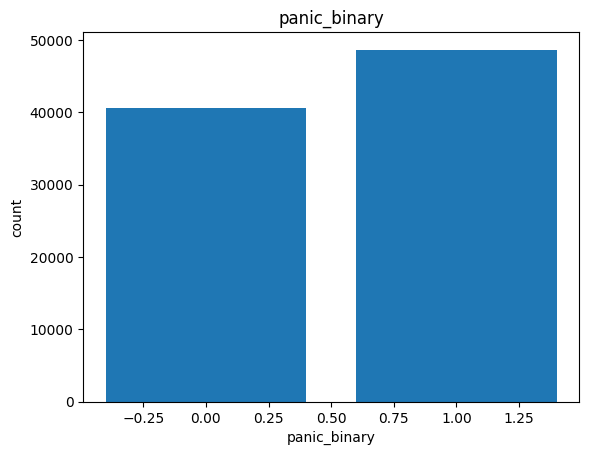

In [9]:
counts = ast_df["panic_binary"].value_counts()

plt.bar(counts.index, counts.values)
plt.title("panic_binary")
plt.xlabel("panic_binary")
plt.ylabel("count")
plt.show()

9. Encode Object Columns + Heatmap

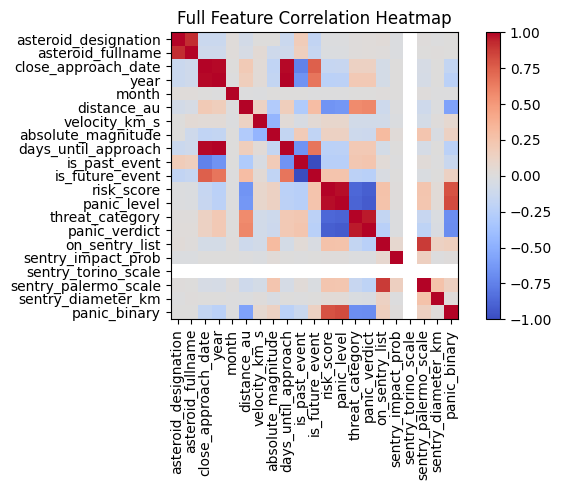

In [10]:
le = LabelEncoder()

for col in ast_df.select_dtypes(include="object").columns:
    ast_df[col] = le.fit_transform(ast_df[col].astype(str))
    
corr = ast_df.corr()

plt.figure(figsize=(7, 5))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(np.arange(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(np.arange(len(corr.columns)), corr.columns)

plt.title("Full Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


This heatmap allowed me to visually inspect how every feature correlates with the others and with the target.

Strong correlations = redundant or leakage‑prone columns
Near‑zero correlations = no predictive value.
I confirmed which columns should be removed (identifiers, constant fields, and highly correlated duplicates) and which ones are meaningful enough to keep for the model.

In [11]:
model_df = ast_df.copy()

10. Drop Unnecessary, Redundant, and Leakage Features

In [12]:
ast_df = ast_df.drop(columns = ['asteroid_designation', 'asteroid_fullname', 'close_approach_date',
       'year', 'month', 'is_past_event', 'is_future_event', 'risk_score',
       'panic_level', 'threat_category', 'panic_verdict', 'sentry_torino_scale'])

11. Check Data Info After Cleaning

In [13]:
ast_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89227 entries, 0 to 89226
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   distance_au           89227 non-null  float64
 1   velocity_km_s         89227 non-null  float64
 2   absolute_magnitude    89183 non-null  float64
 3   days_until_approach   89227 non-null  int64  
 4   on_sentry_list        89227 non-null  bool   
 5   sentry_impact_prob    89227 non-null  float64
 6   sentry_palermo_scale  89227 non-null  float64
 7   sentry_diameter_km    89227 non-null  float64
 8   panic_binary          89227 non-null  int64  
dtypes: bool(1), float64(6), int64(2)
memory usage: 5.5 MB


12. Fill Missing Values + Convert Bool to Int

In [14]:
ast_df['absolute_magnitude'] = ast_df['absolute_magnitude'].fillna(ast_df['absolute_magnitude'].median())
ast_df["on_sentry_list"] = ast_df["on_sentry_list"].astype(int)

I filled missing absolute_magnitude values with the median to keep the feature usable without distorting the distribution. Boolean column (True/False) must be converted to numeric form because ML algorithms require numerical inputs.

13. Describe the Cleaned Dataset

In [15]:
ast_df.describe()

,distance_au,velocity_km_s,absolute_magnitude,days_until_approach,on_sentry_list,sentry_impact_prob,sentry_palermo_scale,sentry_diameter_km,panic_binary
count,89227.000000,89227.000000,89227.000000,89227.000000,89227.000000,89227.000000,89227.000000,89227.000000,89227.000000
mean,0.107744,11.207642,24.113656,9518.961458,0.058682,0.000025,-9.831055,0.010314,0.545463
std,0.057630,5.867671,2.846598,9210.463827,0.235029,0.001306,0.769240,0.009028,0.497932
min,0.000045,0.073451,10.390000,-2119.000000,0.000000,0.000000,-12.140000,0.001090,0.000000
25%,0.058356,6.923423,22.110000,60.500000,0.000000,0.000000,-10.000000,0.010000,0.000000
50%,0.111872,10.184139,24.400000,8238.000000,0.000000,0.000000,-10.000000,0.010000,1.000000
75%,0.158561,14.276625,26.190000,17405.000000,0.000000,0.000000,-10.000000,0.010000,1.000000
max,0.199999,63.401203,32.950000,27464.000000,1.000000,0.102637,-0.920000,1.300000,1.000000


This is where I inspected the ranges and distributions of all numeric features, and confirmed that scaling will be necessary because the numeric ranges are different.

14. Split and Scale Data

In [16]:
X = ast_df.drop(columns=['panic_binary'])
y = ast_df['panic_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state =42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

15. Logistic Regression Model

In [17]:
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

LogisticRegression()

16. Logistic Regression Training Score

In [18]:
log_reg.score(X_train_scaled, y_train)

0.7806979448312577

17. Logistic Regression Predictions

In [19]:
y_pred_log = log_reg.predict(X_test_scaled)

18. Logistic Regression Metrics

In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

Accuracy: 0.7784937801187941
Precision: 0.7974683544303798
Recall: 0.7960756112595028
F1 Score: 0.7967713742224051
Confusion Matrix:
 [[6144 1968]
 [1985 7749]]


19. Random Forest Model

In [21]:
rf = RandomForestClassifier(max_depth=20, min_samples_leaf=35, random_state = 42)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, min_samples_leaf=35, random_state=42)

20. Random Forest Training Score

In [22]:
rf.score(X_train, y_train)

0.9861167537580028

21. Random Forest Predictions

In [23]:
y_pred_rf = rf.predict(X_test)

22. Random Forest Metrics

In [24]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.9770816989801636
Precision: 0.9749414281348681
Recall: 0.9832545716046847
F1 Score: 0.9790803539460897
Confusion Matrix:
 [[7866  246]
 [ 163 9571]]


23. Feature Importance

In [25]:
importances = rf.feature_importances_

feature_names = X.columns

feat_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False).reset_index(drop=True)

feat_importance

,feature,importance
0,distance_au,0.511828
1,days_until_approach,0.391446
2,velocity_km_s,0.039809
3,absolute_magnitude,0.030968
4,sentry_impact_prob,0.009232
5,on_sentry_list,0.008531
6,sentry_palermo_scale,0.005538
7,sentry_diameter_km,0.002648


24. Leakage Investigation

In [26]:
print(model_df[['distance_au', 'velocity_km_s', 'risk_score', 
              'panic_level', 'panic_binary']].corr().round(3))

               distance_au  velocity_km_s  risk_score  panic_level  \
distance_au          1.000          0.129      -0.654       -0.639   
velocity_km_s        0.129          1.000       0.092        0.092   
risk_score          -0.654          0.092       1.000        0.979   
panic_level         -0.639          0.092       0.979        1.000   
panic_binary        -0.571          0.069       0.804        0.821   

               panic_binary  
distance_au          -0.571  
velocity_km_s         0.069  
risk_score            0.804  
panic_level           0.821  
panic_binary          1.000  


These results should be interpreted with caution. The correlation analysis revealed structural leakage between distance_au and the engineered target variable, which likely inflates model performance. The 77.8% accuracy from Logistic Regression is the more conservative and defensible estimate.